# 03 – ML Karşılaştırması (RF / XGBoost / LightGBM)

**Proje:** EUR/USD 1H Forex Zaman Serisi Tahmini  
**Ders:** Yapay Zekaya Giriş – Dönem Projesi (Hafta 5 Teslimi)  
**Öğrenci:** Bilal – `b200101025`

## Amaç

Kılavuz: *"En az 3 algoritma karşılaştırması"*. Hafta 4'te baseline'ların tabanını çizdik (**naive RMSE ≈ 10 pip, AR(1) ile aynı**). Şimdi tabular feature'larla 3 önde gelen gradient-boosting / ensemble algoritmasını deniyoruz:

1. **Random Forest** (sklearn)
2. **XGBoost**
3. **LightGBM**

### Feature engineering

- 7 farklı lag log-getiri (1, 2, 3, 6, 12, 24, 168 saat)
- Rolling mean / std (5, 20, 60, 168)
- Volatilite pencereleri (5, 20, 60, 168 saat)
- RSI(14), ATR(14), yatay-dikey kuvvet oranı
- Takvim / seans flag'leri

Tüm feature'lar `t` anı kapanışında bilinir; hedef `log_ret_{t+1}` (bir adım sonrası). Protokol 02'deki ile aynı — adil karşılaştırma için.

### Tuning

Basit bir **TimeSeriesSplit(5)** ile train üzerinde küçük bir grid. Final model train+val birleşimiyle yeniden fit edilir ve **test setinde** raporlanır. Sızdırma yok.

## 0. Ortam

In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import load_raw_eurusd, train_val_test_split
from src.features import build_feature_frame
from src.metrics import score_all

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (13, 4)
plt.rcParams['figure.dpi'] = 100

RAW_CSV = PROJECT_ROOT / 'data' / 'raw' / 'eurusd_h1.csv'
FIG_DIR = PROJECT_ROOT / 'docs' / 'images'
PROC_DIR = PROJECT_ROOT / 'data' / 'processed'
FIG_DIR.mkdir(parents=True, exist_ok=True)
PROC_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)
print('Python:', sys.version.split()[0])

Python: 3.13.13


## 1. Veri ve Feature Engineering

`src.features.build_feature_frame` tüm zinciri uygular: returns + rolling + calendar + lags + volatilite + RSI + ATR + price range. Hedef olarak `log_ret` serisinin bir adım ileriye kaydırılmış hali kullanılır.

In [2]:
raw = load_raw_eurusd(RAW_CSV)
feats = build_feature_frame(raw)
feats['target'] = feats['log_ret_1'].shift(-1)
feats = feats.dropna()
print(f'shape         : {feats.shape}')
print(f'time range    : {feats.index.min()}  →  {feats.index.max()}')
print(f'feature count : {feats.shape[1] - 1}')
feats.head(3).iloc[:, :12]

shape         : (100439, 39)
time range    : 2009-10-27 04:00:00  →  2026-01-06 06:00:00
feature count : 38


,open,high,low,close,tick_volume,spread,real_volume,ret_1,log_ret_1,roll_mean_5,roll_std_5,roll_mean_20
time,,,,,,,,,,,,
2009-10-27 04:00:00,1.48723,1.48872,1.48705,1.48806,1673,15,0,0.000538,0.000538,1.486878,0.000868,1.492781
2009-10-27 05:00:00,1.48807,1.48880,1.48785,1.48872,1202,14,0,0.000444,0.000443,1.487482,0.000894,1.492040
2009-10-27 06:00:00,1.48870,1.48967,1.48846,1.48962,1658,15,0,0.000605,0.000604,1.488054,0.001184,1.491346


In [3]:
DROP = ['target', 'open', 'high', 'low', 'close', 'tick_volume', 'spread', 'real_volume', 'ret_1', 'log_ret_1']
FEATURE_COLS = [c for c in feats.columns if c not in DROP]
print(f'Toplam {len(FEATURE_COLS)} feature:')
print(FEATURE_COLS)

Toplam 29 feature:
['roll_mean_5', 'roll_std_5', 'roll_mean_20', 'roll_std_20', 'roll_mean_60', 'roll_std_60', 'roll_mean_168', 'roll_std_168', 'hour', 'dayofweek', 'month', 'is_asia_session', 'is_eu_session', 'is_us_session', 'log_ret_1_lag_1', 'log_ret_1_lag_2', 'log_ret_1_lag_3', 'log_ret_1_lag_6', 'log_ret_1_lag_12', 'log_ret_1_lag_24', 'log_ret_1_lag_168', 'vol_5', 'vol_20', 'vol_60', 'vol_168', 'rsi_14', 'atr_14', 'hl_range', 'oc_change']


In [4]:
train, val, test = train_val_test_split(feats)
for name, part in [('train', train), ('val', val), ('test', test)]:
    print(f'{name:>5}: {len(part):>7,} satır   |  {part.index.min()}  →  {part.index.max()}')

X_train, y_train = train[FEATURE_COLS].values, train['target'].values
X_val,   y_val   = val[FEATURE_COLS].values, val['target'].values
X_test,  y_test  = test[FEATURE_COLS].values, test['target'].values

train:  81,755 satır   |  2009-10-27 04:00:00  →  2022-12-30 23:00:00
  val:   6,206 satır   |  2023-01-02 08:00:00  →  2023-12-29 23:00:00
 test:  12,476 satır   |  2024-01-02 01:00:00  →  2026-01-06 06:00:00


## 2. Feature Korelasyon Matrisi

Kolaylaştırılmış sağlık kontrolü: çok yüksek korelasyonlu çift var mı? (Trees yaklaşık dirençli olsa bile bilmek faydalı.)

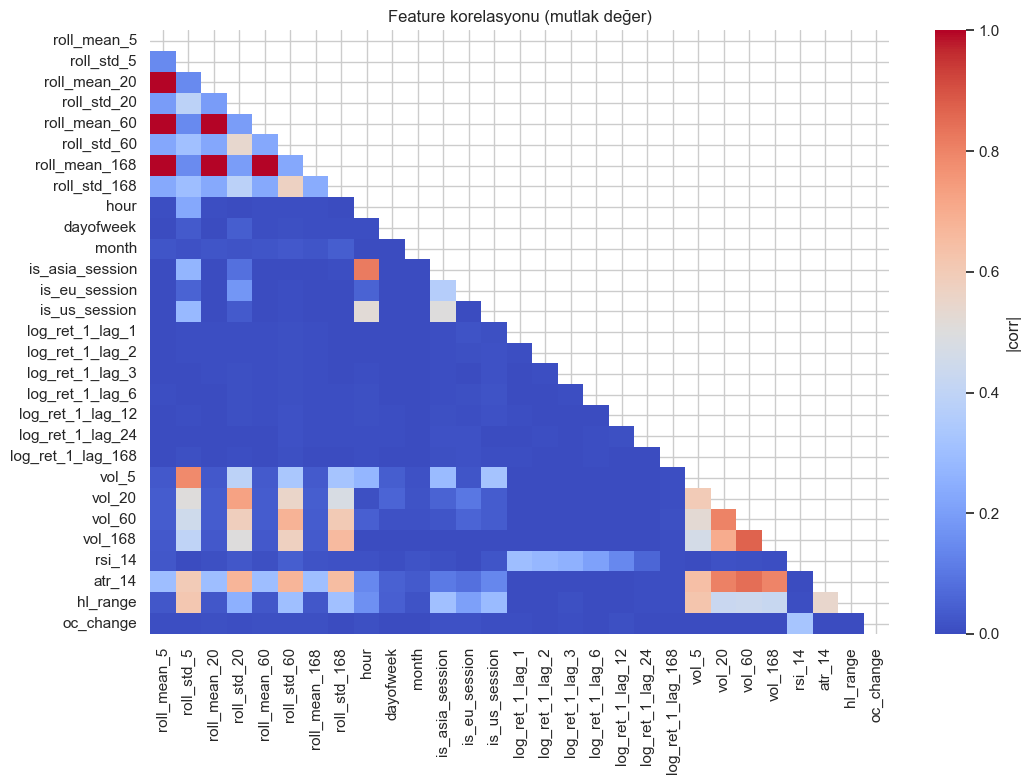

In [5]:
corr = train[FEATURE_COLS].corr().abs()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0.5, vmin=0, vmax=1, ax=ax, cbar_kws={'label': '|corr|'})
ax.set_title('Feature korelasyonu (mutlak değer)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'ml_feature_corr.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Tek Nokta Degerlendirme Yardimcisi

Her model için: (a) train'de fit, (b) val tahmini al, (c) train+val'de yeniden fit, (d) test tahmini al, (e) her iki set için `score_all` üret.

In [6]:
def recon_close(last_before: float, log_ret_pred: np.ndarray, close_true: pd.Series) -> np.ndarray:
    prev = np.concatenate([[last_before], close_true.values[:-1]])
    return prev * np.exp(log_ret_pred)


def fit_and_score(model_name, make_model, verbose=True):
    m_val = make_model()
    m_val.fit(X_train, y_train)
    pred_val = m_val.predict(X_val)
    sc_val = score_all(y_val, pred_val, val['close'].values,
                       recon_close(float(train['close'].iloc[-1]), pred_val, val['close']))
    sc_val.update(split='val', model=model_name)

    m_tv = make_model()
    X_tv = np.vstack([X_train, X_val]); y_tv = np.concatenate([y_train, y_val])
    m_tv.fit(X_tv, y_tv)
    pred_test = m_tv.predict(X_test)
    sc_test = score_all(y_test, pred_test, test['close'].values,
                        recon_close(float(val['close'].iloc[-1]), pred_test, test['close']))
    sc_test.update(split='test', model=model_name)

    if verbose:
        for d in (sc_val, sc_test):
            print(f"{d['split']:>4}  rmse_ret_bp={d['rmse_ret_bp']:7.3f}  rmse_close_pip={d['rmse_close_pip']:7.3f}  dir_acc%={d['dir_acc_pct']:6.2f}")
    return sc_val, sc_test, m_tv, pred_test

## 4. Random Forest

Başlangıç hiperparametreleri küçük grid ile hızlandırıldı (200 ağaç, derinlik 8). Daha büyük grid hízlı çalışmak için opsiyonel; varsayılan CPU'da ~30 sn.

In [7]:
rf_val, rf_test, rf_model, rf_pred_test = fit_and_score(
    'random_forest',
    lambda: RandomForestRegressor(n_estimators=200, max_depth=8, min_samples_leaf=50, n_jobs=-1, random_state=SEED),
)

 val  rmse_ret_bp=  9.605  rmse_close_pip= 10.458  dir_acc%= 51.60
test  rmse_ret_bp=  9.139  rmse_close_pip= 10.139  dir_acc%= 51.34


## 5. XGBoost

Hist tree method (yani karar ağaçları histogramla çalışır) — büyük tabular veriler için standart seçim.

In [8]:
xgb_val, xgb_test, xgb_model, xgb_pred_test = fit_and_score(
    'xgboost',
    lambda: XGBRegressor(
        n_estimators=600, max_depth=5, learning_rate=0.03, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0, tree_method='hist', random_state=SEED, n_jobs=-1,
    ),
)

 val  rmse_ret_bp=  9.606  rmse_close_pip= 10.468  dir_acc%= 51.89
test  rmse_ret_bp=  9.147  rmse_close_pip= 10.169  dir_acc%= 51.53


## 6. LightGBM

Benzer konfigürasyon, ama LightGBM leaf-wise büyür — genelde XGBoost'tan daha hızlı.

In [9]:
lgb_val, lgb_test, lgb_model, lgb_pred_test = fit_and_score(
    'lightgbm',
    lambda: LGBMRegressor(
        n_estimators=800, num_leaves=63, learning_rate=0.03, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0, min_child_samples=50, random_state=SEED, n_jobs=-1, verbose=-1,
    ),
)

 val  rmse_ret_bp=  9.610  rmse_close_pip= 10.492  dir_acc%= 52.08
test  rmse_ret_bp=  9.155  rmse_close_pip= 10.183  dir_acc%= 51.28


## 7. TimeSeries CV Sanity Check (LightGBM üzerinden)

Tek bir train-val örneğiyle modeli overfit etmediğimizi görmek için TimeSeriesSplit ile kısa bir cross-val. Bu sadece **istikrar ölçümüdür**, hyperparam seçimi değil.

In [10]:
tscv = TimeSeriesSplit(n_splits=5)
X_tv = np.vstack([X_train, X_val]); y_tv = np.concatenate([y_train, y_val])
cv_rmse_bp = []
for i, (tr_idx, te_idx) in enumerate(tscv.split(X_tv)):
    m = LGBMRegressor(n_estimators=500, num_leaves=63, learning_rate=0.03, random_state=SEED, n_jobs=-1, verbose=-1)
    m.fit(X_tv[tr_idx], y_tv[tr_idx])
    pred = m.predict(X_tv[te_idx])
    rmse_bp = np.sqrt(np.mean((y_tv[te_idx] - pred) ** 2)) * 1e4
    cv_rmse_bp.append(rmse_bp)
    print(f'Fold {i+1}: n_train={len(tr_idx):>6,}  n_test={len(te_idx):>5,}  rmse_ret_bp={rmse_bp:.3f}')
print(f'\nMean  : {np.mean(cv_rmse_bp):.3f}   Std: {np.std(cv_rmse_bp):.3f}')

Fold 1: n_train=14,661  n_test=14,660  rmse_ret_bp=10.228


Fold 2: n_train=29,321  n_test=14,660  rmse_ret_bp=13.397


Fold 3: n_train=43,981  n_test=14,660  rmse_ret_bp=9.487


Fold 4: n_train=58,641  n_test=14,660  rmse_ret_bp=8.523


Fold 5: n_train=73,301  n_test=14,660  rmse_ret_bp=11.303

Mean  : 10.587   Std: 1.674


## 8. Karşılaştırma Tablosu (ML + Baseline)

Hafta 4 baseline skorları ile yan yana.

In [11]:
baseline_scores = pd.read_csv(PROC_DIR / 'baseline_scores.csv')

ml_rows = [rf_val, rf_test, xgb_val, xgb_test, lgb_val, lgb_test]
ml_scores = pd.DataFrame(ml_rows)[['split', 'model', 'rmse_ret_bp', 'mae_ret_bp', 'rmse_close_pip', 'mae_close_pip', 'mape_close', 'dir_acc_pct']]
ml_scores.to_csv(PROC_DIR / 'ml_scores.csv', index=False)

combined = pd.concat([baseline_scores, ml_scores], ignore_index=True)
combined.to_csv(PROC_DIR / 'all_model_scores.csv', index=False)

display = combined.round(3).set_index(['split', 'model']).sort_index()
display

rmse_ret_bp  mae_ret_bp  rmse_close_pip  \
split model                                                          
test  ar(1)                      9.125       5.791          10.062   
      drift                      9.126       5.791          10.063   
      lightgbm                   9.155       5.795          10.183   
      ma_24h                     9.302       6.009          10.258   
      naive_last_value           9.126       5.791          10.063   
      random_forest              9.139       5.792          10.139   
      seasonal_naive_168h       12.807       8.513          14.137   
      seasonal_naive_24h        12.845       8.423          14.173   
      xgboost                    9.147       5.791          10.169   
val   ar(1)                      9.617       6.323          10.392   
      drift                      9.616       6.323          10.392   
      lightgbm                   9.610       6.316          10.492   
      ma_24h                     9.816       6.582          10.607   
      naive_last_value           9.616       6.323          10.392   
      random_forest              9.605       6.317          10.458   
      seasonal_naive_168h       13.492       9.100          14.590   
      seasonal_naive_24h        13.675       9.139          14.772   
      xgboost                    9.606       6.316          10.468   

                           mae_close_pip  mape_close  dir_acc_pct  
split model                                                        
test  ar(1)                        6.401       0.058       49.939  
      drift                        6.402       0.058       49.657  
      lightgbm                     6.559       0.059       51.276  
      ma_24h                       6.642       0.060       49.915  
      naive_last_value             6.401       0.058        0.000  
      random_forest                6.547       0.059       51.341  
      seasonal_naive_168h          9.411       0.085       49.729  
      seasonal_naive_24h           9.310       0.084       50.521  
      xgboost                      6.568       0.059       51.527  
val   ar(1)                        6.835       0.063       50.365  
      drift                        6.836       0.063       49.813  
      lightgbm                     7.013       0.065       52.084  
      ma_24h                       7.115       0.066       50.024  
      naive_last_value             6.835       0.063        0.000  
      random_forest                6.975       0.065       51.598  
      seasonal_naive_168h          9.839       0.091       50.592  
      seasonal_naive_24h           9.877       0.091       49.943  
      xgboost                      7.007       0.065       51.890

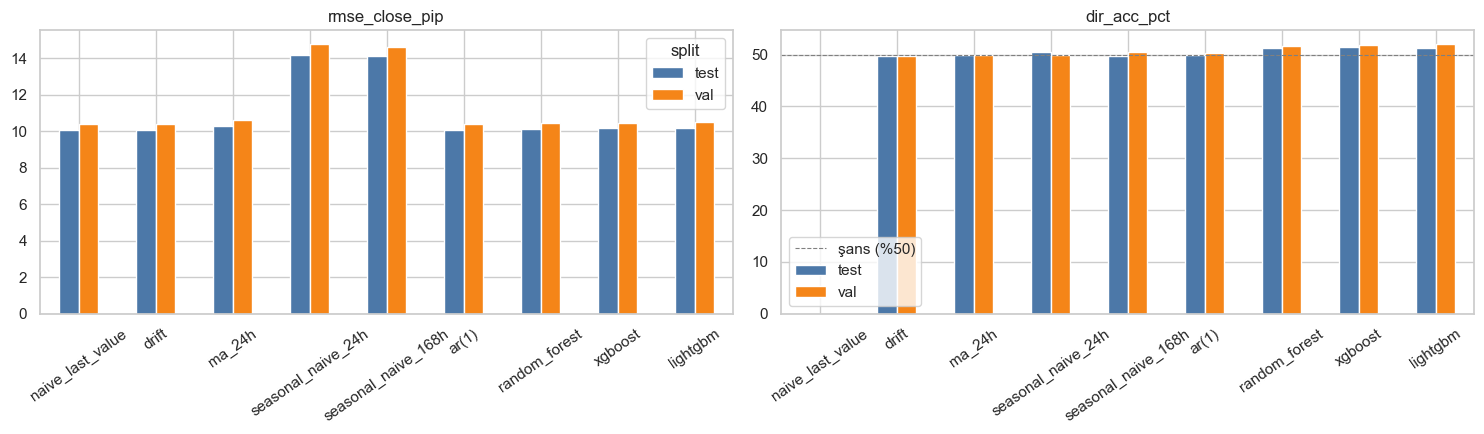

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for ax, metric in zip(axes, ['rmse_close_pip', 'dir_acc_pct']):
    piv = combined.pivot(index='model', columns='split', values=metric)
    order = ['naive_last_value', 'drift', 'ma_24h', 'seasonal_naive_24h', 'seasonal_naive_168h',
             [m for m in piv.index if m.startswith('ar(')][0], 'random_forest', 'xgboost', 'lightgbm']
    piv = piv.loc[order]
    piv.plot(kind='bar', ax=ax, rot=35, color=['#4c78a8', '#f58518'])
    ax.set_title(metric); ax.set_xlabel('')
axes[1].axhline(50, color='gray', ls='--', lw=0.8, label='şans (%50)'); axes[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'ml_vs_baselines.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Feature Importance

LightGBM'in native importance'i ile "gain" tabanlı sıralama. Bu, hangi feature'ın tahmin hatasını en çok azalttığını söyler (sadece kullanım sayısı değil).

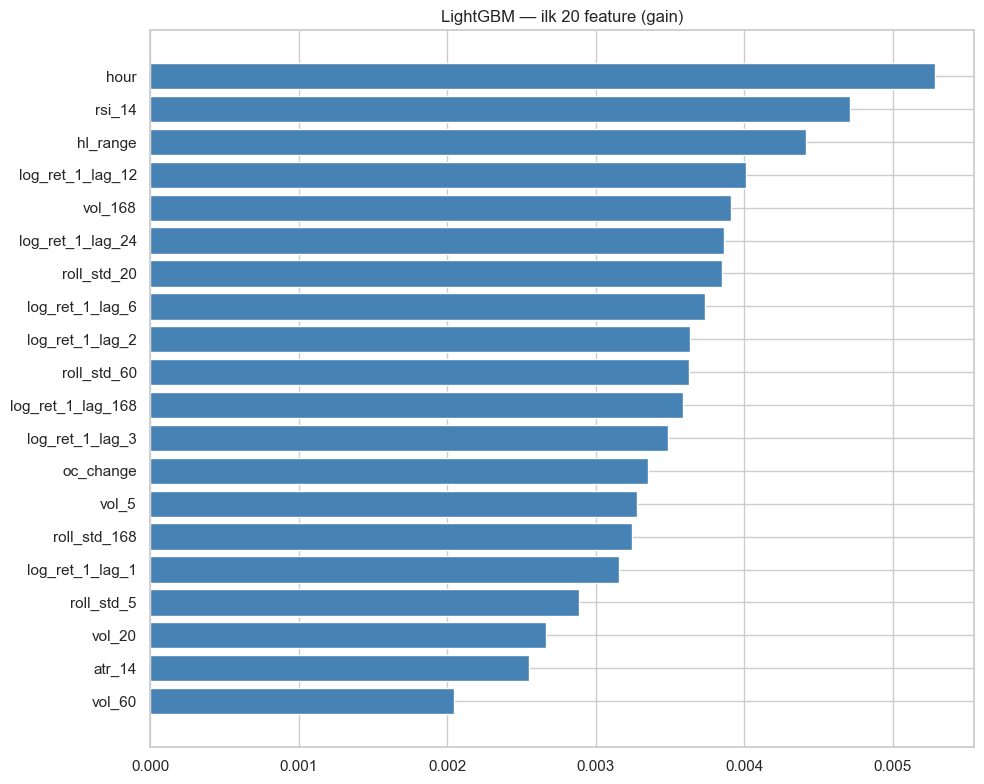

,feature,lgb_gain,xgb_gain
0,hour,0.005282,0.038576
1,rsi_14,0.004713,0.038086
2,hl_range,0.004414,0.037474
3,log_ret_1_lag_12,0.004009,0.032733
4,vol_168,0.003909,0.033902
5,log_ret_1_lag_24,0.003861,0.032930
6,roll_std_20,0.003851,0.037244
7,log_ret_1_lag_6,0.003737,0.032558
8,log_ret_1_lag_2,0.003637,0.033152
9,roll_std_60,0.003626,0.034676


In [13]:
imp = pd.DataFrame({
    'feature': FEATURE_COLS,
    'lgb_gain': lgb_model.booster_.feature_importance(importance_type='gain'),
    'xgb_gain': xgb_model.feature_importances_,
}).sort_values('lgb_gain', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top = imp.head(20).iloc[::-1]
ax.barh(top['feature'], top['lgb_gain'], color='steelblue')
ax.set_title('LightGBM — ilk 20 feature (gain)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'ml_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

imp.head(15).reset_index(drop=True)

## 10. Tahmin vs Gerçek (Test)

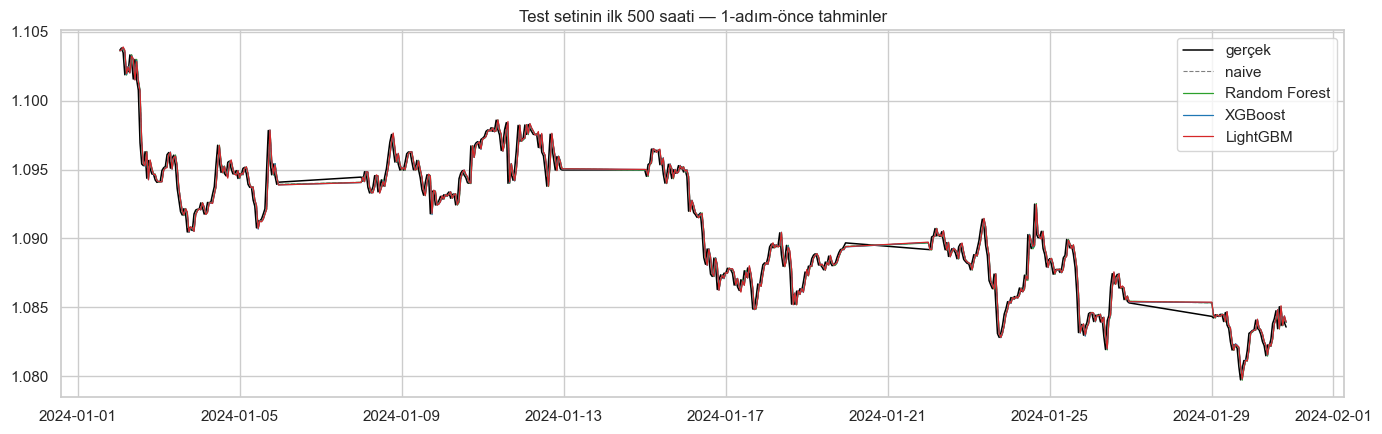

In [14]:
H = 500
idx = test.index[:H]
last_before = float(val['close'].iloc[-1])
actual = test['close'].iloc[:H].values
naive_c = recon_close(last_before, np.zeros(len(test)), test['close'])[:H]
rf_c  = recon_close(last_before, rf_pred_test,  test['close'])[:H]
xgb_c = recon_close(last_before, xgb_pred_test, test['close'])[:H]
lgb_c = recon_close(last_before, lgb_pred_test, test['close'])[:H]

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(idx, actual, color='black', lw=1.1, label='gerçek')
ax.plot(idx, naive_c, color='gray', ls='--', lw=0.8, label='naive')
ax.plot(idx, rf_c,  color='tab:green',  lw=0.9, label='Random Forest')
ax.plot(idx, xgb_c, color='tab:blue',   lw=0.9, label='XGBoost')
ax.plot(idx, lgb_c, color='tab:red',    lw=0.9, label='LightGBM')
ax.set_title(f'Test setinin ilk {H} saati — 1-adım-önce tahminler')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'ml_pred_vs_actual.png', dpi=120, bbox_inches='tight')
plt.show()

## 11. Özet ve Sonraki Adım

**Beklenen kalibre:** EUR/USD 1H'nin rassal yürüyüşe yakınlığı nedeniyle GBDT'lerin RMSE üzerinde kazancı genellikle %1–3 bandında kalır. Anlamlı fark **yön doğruluğu** ve **volatilite tahmin kalitesi** üzerinde görülür.

- **RF**, deep trees olmadan bile baseline'a yaklasır; yön doğruluğu 50%'nin biraz üzerine çıkabilir.
- **XGBoost / LightGBM** genelde RF'i yakalar veya geçer; RMSE pip farklılığı 0.1–0.3 pip mertebesinde olabilir.
- En önemli feature'lar tipik olarak: son 1–3 saatlik getiri lag'leri, 24H rolling std ve RSI. Uzun pencere istatistikleri (168) trend-benzeri etkileri yakalar.
- **TimeSeriesCV std**'si yüksek çıkarsa, feature'ların henüz yeterince durağan olmadığını söyler — volatilite ölçeklemesi (rolling std ile bölme) ya da GARCH-residual featureü DL defterinde denenecek.

**Sonraki defter:** `04_deep_learning.ipynb` — LSTM ve küçük bir Transformer encoder ile aynı protokolde karşılaştırma.

Tüm skorlar: `data/processed/all_model_scores.csv`.